# Проект: классификация

In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [224]:
df = pd.read_csv(r'data\bank_fin.zip', sep = ';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,"2 343,00 $",yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,"45,00 $",no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,"1 270,00 $",yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,"2 476,00 $",yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,"184,00 $",no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [225]:
# исследуйте данные на предмет пропусков. Где есть пропущенные значения? Сколько их?
# ваш код

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11137 non-null  object
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(6), object(11)
memory usage: 1.4+ MB


In [226]:
df.balance.isna().sum()

np.int64(25)

### Задание 2

In [227]:
# есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?
# ваш код
df['balance'].value_counts()

balance
0  $             774
 1,00 $           39
 2,00 $           34
 3,00 $           34
 4,00 $           29
                ... 
 2 593,00 $        1
 1 594,00 $        1
-325,00 $          1
 3 872,00 $        1
 20 772,00 $       1
Name: count, Length: 3802, dtype: int64

### Задание 3

In [228]:
# преобразуйте признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)

df['balance'] = df['balance'].apply(lambda x : str(x).replace('$', '').replace(',', '.').replace(' ', ''))
df.balance = df.balance.apply(lambda x : np.nan if x == '' else float(x))
df.balance

0        2343.0
1          45.0
2        1270.0
3        2476.0
4         184.0
          ...  
11157       1.0
11158     733.0
11159      29.0
11160       0.0
11161       0.0
Name: balance, Length: 11162, dtype: float64

In [229]:
print(round(df.balance.mean(), 3))

1529.129


### Задание 4

In [230]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку
# ваш код

balance_median = df.balance.median()
df.balance.fillna(balance_median, inplace=True)
print(round(df.balance.mean(),3))

1526.936


### Задание 5

In [231]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения
# ваш код

mode_job = df.job.mode()[0]
mode_education = df.education.mode()[0]

df.job = df.job.replace('unknown', mode_job)
df.education = df.education.replace('unknown', mode_education)

top_job_mask = df['job'] == mode_job
top_education_mask = df['education'] == mode_education

mode_education_and_job_clients = round(df[top_education_mask & top_job_mask]['balance'].mean(), 3)
mode_education_and_job_clients

np.float64(1598.883)

### Задание 6

In [232]:
# удалите все выбросы для признака balance
# ваш код

q1 = df.balance.quantile(0.25)
q3 = df.balance.quantile(0.75)
iqr = q3 - q1
low_border = round(q1 - 1.5 * iqr)
top_border = round(q3 + 1.5 * iqr)
top_border

df = df[(df['balance'] >= low_border) & (df['balance'] <= top_border)]
df.balance.shape

(10105,)

## Часть 2:  Разведывательный анализ

### Задание 1

In [233]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

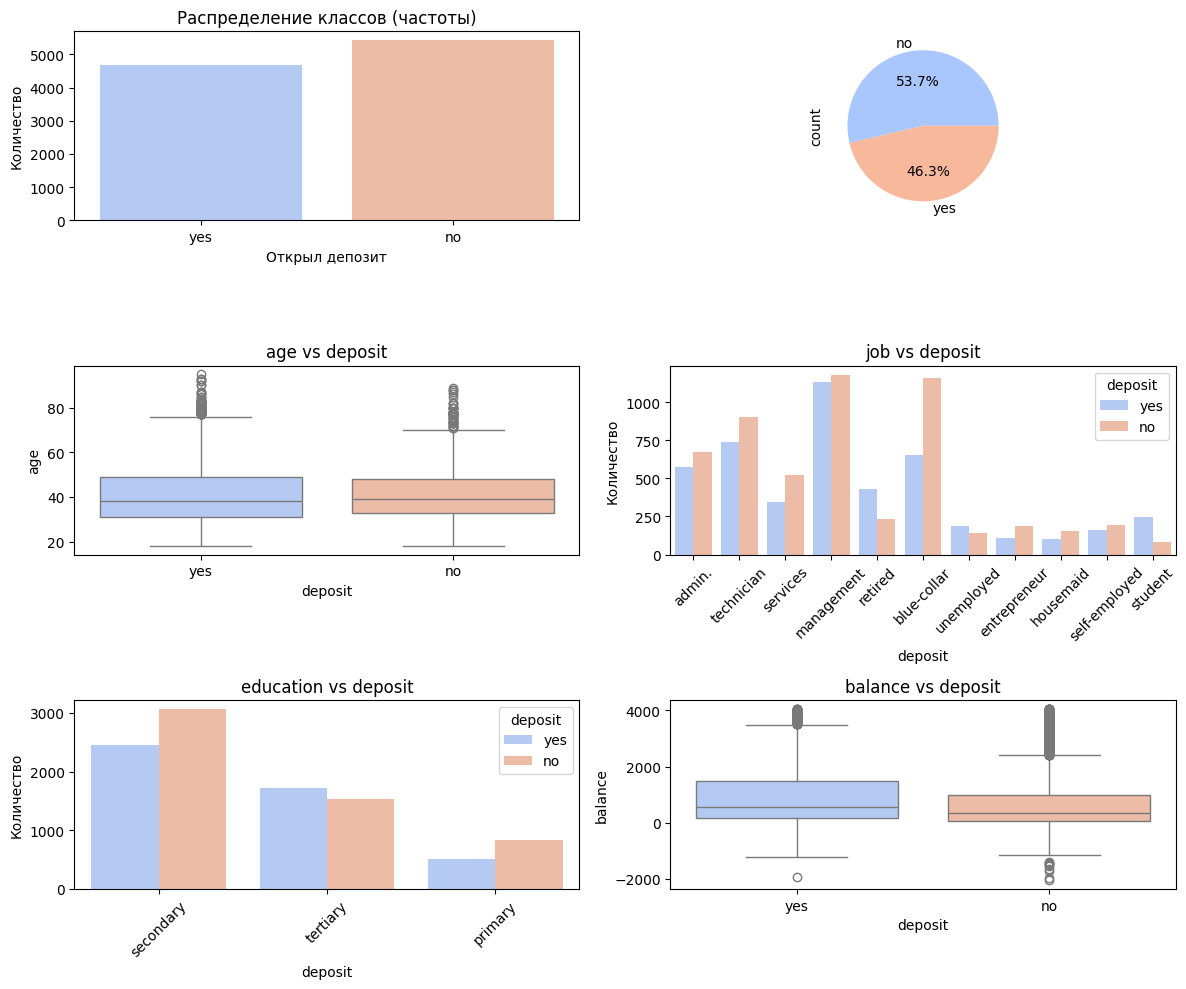

In [234]:

feats = ['age', 'job', 'education', 'balance']
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))

# столбчатая диаграмма частот
sns.countplot(x='deposit', data=df, palette='coolwarm', ax=ax[0, 0])
ax[0, 0].set_title('Распределение классов (частоты)')
ax[0, 0].set_xlabel('Открыл депозит')
ax[0, 0].set_ylabel('Количество')

# круговая диаграмма для долей
df['deposit'].value_counts().plot(
    kind='pie',
    autopct='%.1f%%',
    colors=sns.color_palette('coolwarm', 2),
    ax=ax[0, 1]
)

axes = ax.flatten()[2:]  # пропускаем первые две ячейки, где у тебя уже графики deposit

for feat, axis in zip(feats, axes):
    if df[feat].dtype == 'object':
        sns.countplot(x=feat, hue='deposit', data=df, ax=axis, palette='coolwarm')
        axis.tick_params(axis='x', rotation=45)
        axis.set_ylabel('Количество')
    else:
        sns.boxplot(x='deposit', y=feat, data=df, ax=axis, palette='coolwarm')
        axis.set_ylabel(feat)
    axis.set_title(f'{feat} vs deposit')
    axis.set_xlabel('deposit')

plt.tight_layout()
plt.show()


In [235]:
df.deposit.value_counts()

deposit
no     5424
yes    4681
Name: count, dtype: int64

In [236]:
df['marital'].value_counts()

marital
married     5715
single      3213
divorced    1177
Name: count, dtype: int64

In [237]:
df.month.value_counts()

month
may    2617
jul    1418
aug    1385
jun    1104
apr     830
nov     780
feb     709
oct     335
jan     319
sep     278
mar     237
dec      93
Name: count, dtype: int64

In [238]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000
mean,40.895497,807.653538,15.590302,368.742603,2.517170,51.319644,0.816230
std,11.734931,994.151966,8.441510,346.651524,2.707159,109.644179,2.243795
min,18.000000,-2049.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,95.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,38.000000,445.000000,15.000000,252.000000,2.000000,-1.000000,0.000000
75%,48.000000,1227.000000,22.000000,490.000000,3.000000,2.000000,1.000000
max,95.000000,4063.000000,31.000000,3881.000000,43.000000,854.000000,58.000000


### Задания 2 и 3

In [239]:
#рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат
#ваш код

### Задания 4 и 5

In [240]:
#рассчитайте описательные статистики для категориальных переменных, проинтерпретируйте результат
#ваш код
#постройте визуализации, иллюстрирующие результаты

### Задание 6

In [241]:
# Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.
# ваш код

df.poutcome.value_counts()


poutcome
unknown    7570
failure    1109
success     945
other       481
Name: count, dtype: int64

### Задание 7

In [242]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
# ваш код
dfg = df[df['deposit'] == 'no']
dfg =  dfg.groupby(by='month')['poutcome'].count()/ df.groupby(by='month')['poutcome'].count()
dfg

month
apr    0.381928
aug    0.559567
dec    0.096774
feb    0.455571
jan    0.608150
jul    0.589563
jun    0.548913
mar    0.101266
may    0.678640
nov    0.584615
oct    0.185075
sep    0.165468
Name: poutcome, dtype: float64

### Задание 8

In [243]:
# создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения

def create_age_group(age):
    if age < 30:
        return '<30'
    elif age >= 30 and age <= 40:
        return '30-40'
    elif age >= 41 and age <= 50:
        return '40-50'
    elif age >= 51 and age <= 60:
        return '50-60'
    elif age > 60:
        return '60+'

In [244]:
df['age_group'] = df.age.apply(create_age_group)

Text(0.5, 1.0, 'deposit vs age_group')

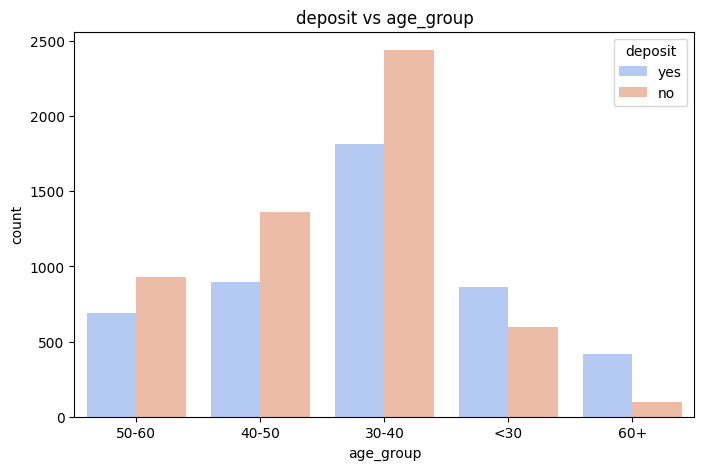

In [245]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='age_group',
    hue='deposit',
    palette='coolwarm'
)
plt.title('deposit vs age_group')

### Задания 9 и 10

<Axes: xlabel='marital', ylabel='count'>

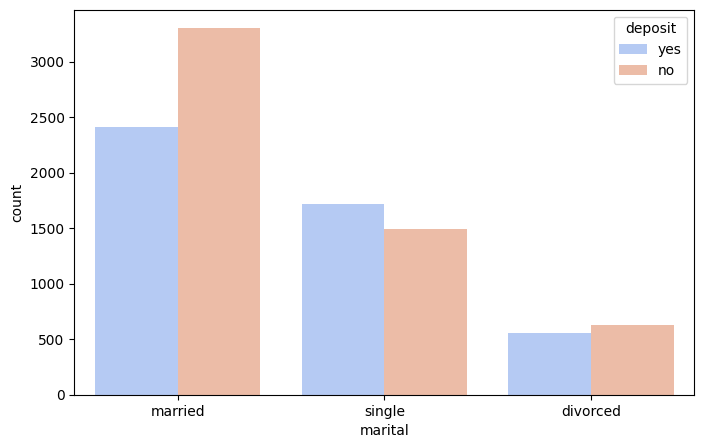

In [246]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от семейного статуса

plt.subplots(figsize = (8, 5))
sns.countplot(x=df.marital, hue=df.deposit, palette='coolwarm')

<Axes: xlabel='education', ylabel='count'>

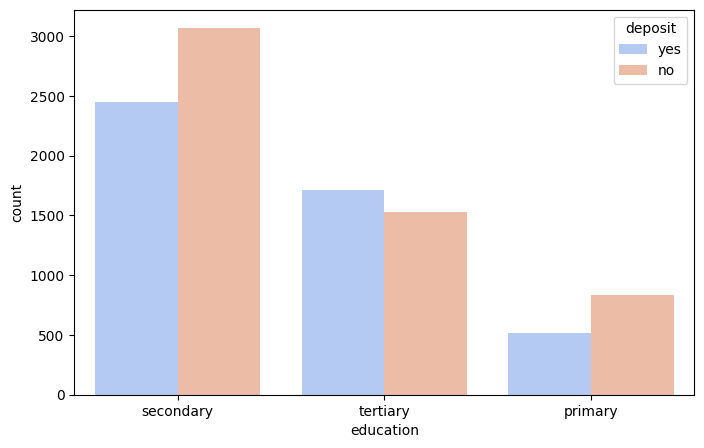

In [247]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от образования
plt.subplots(figsize = (8, 5))
sns.countplot(x=df.education, hue=df.deposit, palette='coolwarm')

<Axes: xlabel='job', ylabel='count'>

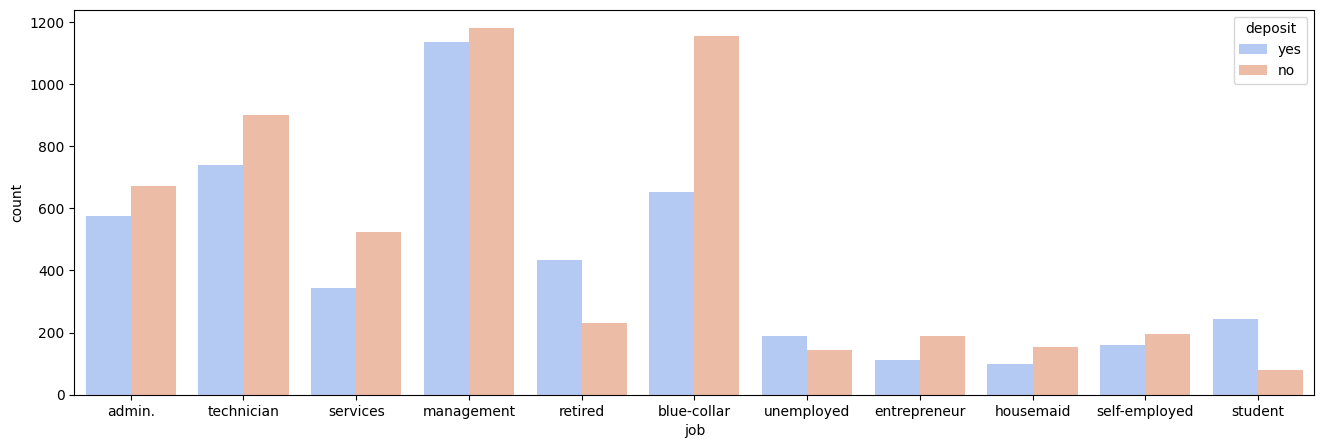

In [248]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости

plt.subplots(figsize = (16, 5))
sns.countplot(x=df.job, hue=df.deposit, palette='coolwarm')

### Задание 11

Text(95.72222222222221, 0.5, 'Образование')

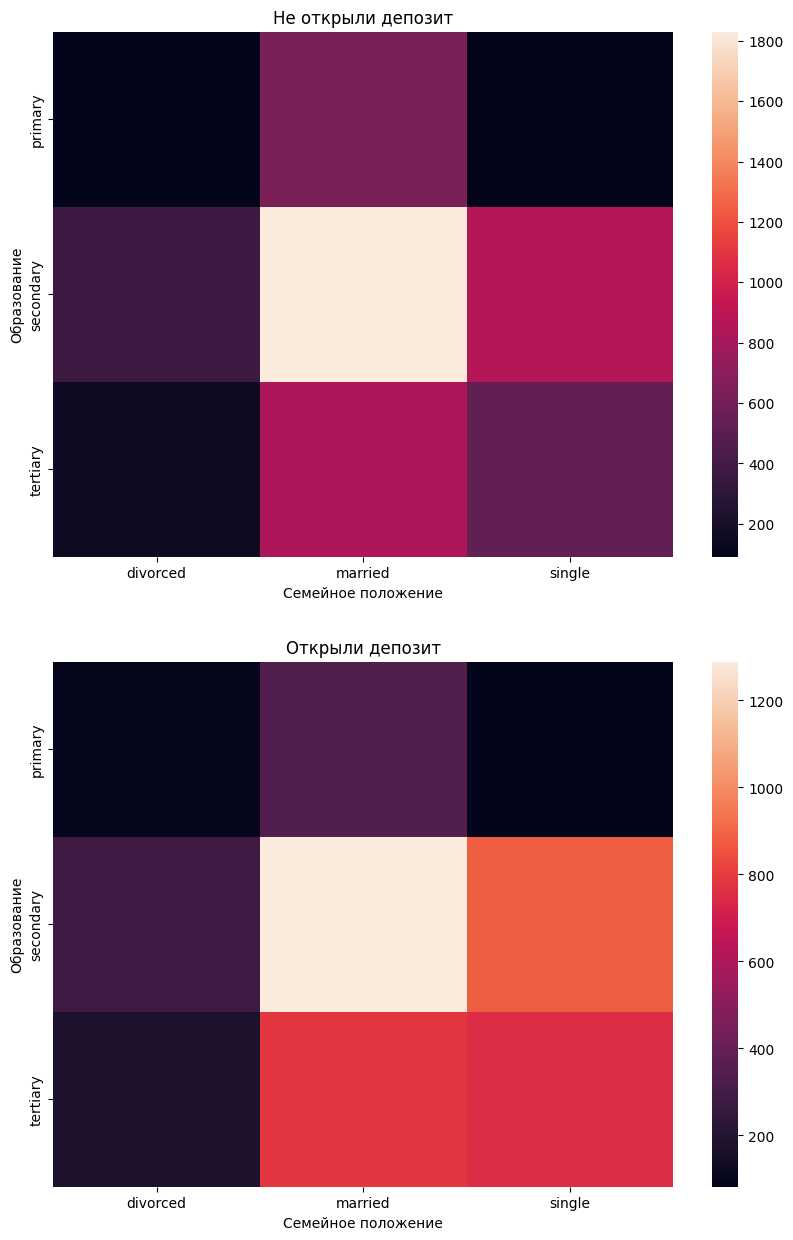

In [249]:
# постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны
#(если рассматривать тех, кто открыл депозит)

not_open_deposit = df[df['deposit'] == 'no']
open_deposit = df[df['deposit'] == 'yes']


pt_not_open_deposit = pd.pivot_table(
    not_open_deposit,
    values='age_group',
    index='education',
    columns='marital',
    aggfunc='count'
    )

pt_open_deposit = pd.pivot_table(
    open_deposit,
    values='age_group',
    index='education',
    columns='marital',
    aggfunc='count'
    )


fig, axis = plt.subplots(nrows=2, ncols=1, figsize = (10, 15))
sns.heatmap(data=pt_not_open_deposit, ax=axis[0])
axis[0].set_title('Не открыли депозит')
axis[0].set_xlabel('Семейное положение')
axis[0].set_ylabel('Образование')
sns.heatmap(data=pt_open_deposit, ax=axis[1])
axis[1].set_title('Открыли депозит')
axis[1].set_xlabel('Семейное положение')
axis[1].set_ylabel('Образование')



## Часть 3: преобразование данных

### Задание 1

In [250]:
# преобразуйте уровни образования

le = LabelEncoder()
df.education = le.fit_transform(df.education)
df.education.sum()

np.int64(11995)

### Задания 2 и 3

In [251]:
# преобразуйте бинарные переменные в представление из нулей и единиц
df['deposit'] = le.fit_transform(df.deposit)
df['age_group'] = le.fit_transform(df.age_group)
df['default'] = le.fit_transform(df.default)
df['housing'] = le.fit_transform(df.housing)
df['loan'] = le.fit_transform(df.loan)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group
0,59,admin.,married,1,0,2343.0,1,0,unknown,5,may,1042,1,-1,0,unknown,1,2
1,56,admin.,married,1,0,45.0,0,0,unknown,5,may,1467,1,-1,0,unknown,1,2
2,41,technician,married,1,0,1270.0,1,0,unknown,5,may,1389,1,-1,0,unknown,1,1
3,55,services,married,1,0,2476.0,1,0,unknown,5,may,579,1,-1,0,unknown,1,2
4,54,admin.,married,2,0,184.0,0,0,unknown,5,may,673,2,-1,0,unknown,1,2


In [252]:
round(df.default.mean() + df.loan.mean() + df.housing.mean(), 3)

np.float64(0.635)

### Задание 4

In [253]:
# создайте дамми-переменные
arr = ['job', 'marital', 'contact', 'month', 'poutcome']
df = pd.get_dummies(data = df, columns=arr, drop_first=True)


In [254]:
df.shape

(10105, 41)

### Задания 5 и 6

<Axes: >

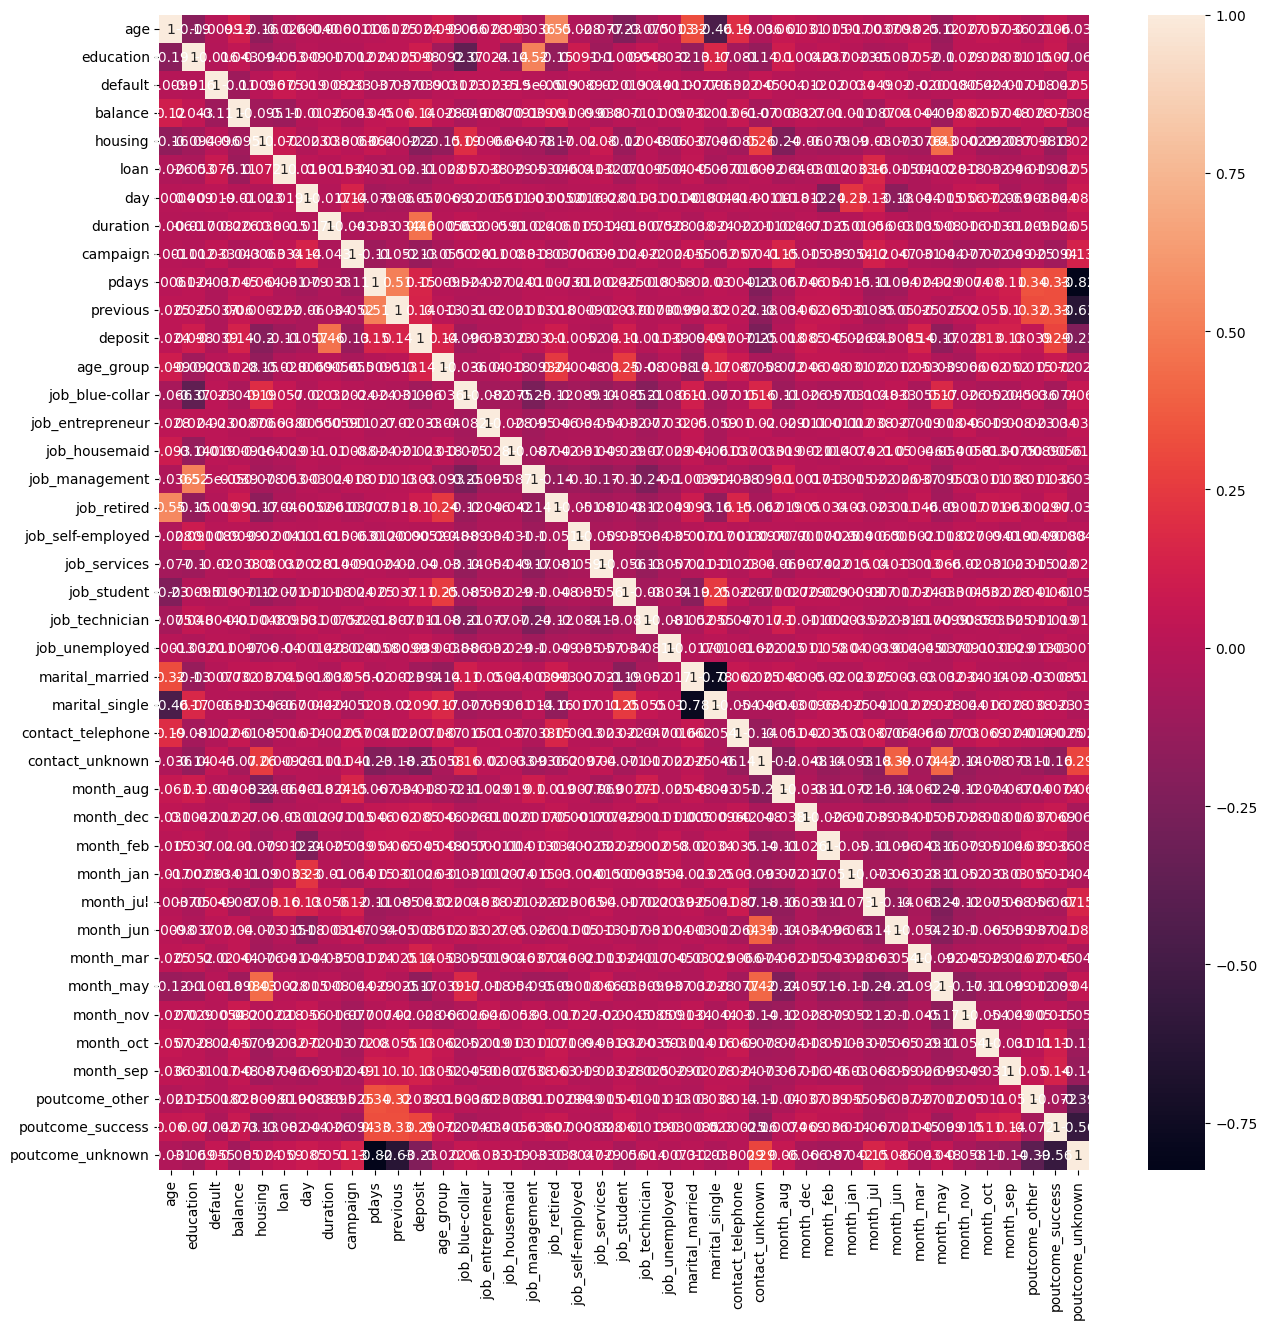

In [255]:
# постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности
plt.subplots(figsize = (15, 15))
corr_matrix = df.corr()
sns.heatmap(data=corr_matrix, annot=True)

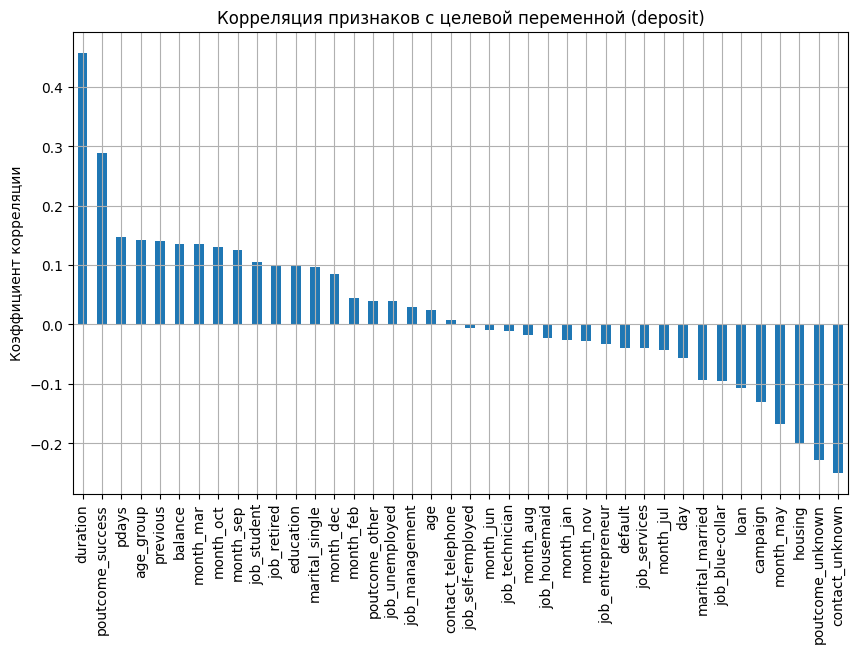

In [256]:
corr_with_target = corr_matrix['deposit'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
corr_with_target.drop('deposit').plot(kind='bar')
plt.title('Корреляция признаков с целевой переменной (deposit)')
plt.ylabel('Коэффициент корреляции')
plt.grid(True)
plt.show()

### Задания 7 и 8

In [257]:
X = df.drop(['deposit'], axis=1)
y = df['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [258]:
# рассчитайте необходимые показатели
y_test.mean()

np.float64(0.46326836581709147)

### Задание 9

In [259]:
# с помощью SelectKBest отберите 15 наиболее подходящих признаков

selector = SelectKBest(k=15, score_func=f_classif)
X_train_k_best = selector.fit_transform(X_train, y_train)
X_test_k_best = selector.transform(X_test)

In [260]:
selector.get_feature_names_out()

array(['balance', 'housing', 'loan', 'duration', 'campaign', 'pdays',
       'previous', 'age_group', 'contact_unknown', 'month_mar',
       'month_may', 'month_oct', 'month_sep', 'poutcome_success',
       'poutcome_unknown'], dtype=object)

### Задание 10

In [261]:
# нормализуйте данные с помощью minmaxsxaler
from sklearn.preprocessing import MinMaxScaler

min_max_sc = MinMaxScaler()
X_train_k_best_sc = min_max_sc.fit_transform(X_train_k_best)
X_test_k_best_sc = min_max_sc.transform(X_test_k_best)

In [262]:
round(X_test_k_best_sc[:, 0].mean(), 2)

np.float64(0.47)

# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [263]:
# обучите логистическую регрессию и рассчитайте метрики качества

lr = linear_model.LogisticRegression(random_state=42, solver='sag', max_iter=1000)

lr.fit(X_train_k_best_sc, y=y_train)

y_lr_pred = lr.predict(X_test_k_best_sc)
print(round(metrics.accuracy_score(y_pred=y_lr_pred, y_true=y_test),2))

0.81


### Задания 2,3,4

In [264]:
# обучите решающие деревья, настройте максимальную глубину

dt = tree.DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=1000)

dt.fit(X_train_k_best_sc, y=y_train)
y_ds_pred =  dt.predict(X_test_k_best_sc)
print((metrics.classification_report(y_pred=y_ds_pred, y_true=y_test)))

              precision    recall  f1-score   support

           0       0.77      0.77      0.77      1790
           1       0.74      0.73      0.73      1545

    accuracy                           0.75      3335
   macro avg       0.75      0.75      0.75      3335
weighted avg       0.75      0.75      0.75      3335



### Задание 5

In [265]:
# подберите оптимальные параметры с помощью gridsearch
from sklearn.model_selection import GridSearchCV

param_grid = {
    'min_samples_split': [2, 5, 7, 10],
    'max_depth':[3,5,7],
}

gs = GridSearchCV(estimator=dt, param_grid=param_grid, scoring='f1', n_jobs=-1, cv=5)

gs.fit(X_train_k_best_sc, y_train)
best_ds = gs.best_estimator_

y_ds_pred = best_ds.predict(X_test_k_best_sc)
print(metrics.f1_score(y_pred=y_ds_pred, y_true=y_test))

0.8066474912112496


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [266]:
# обучите на ваших данных случайный лес

rf = ensemble.RandomForestClassifier(
    
    n_estimators = 100,
    criterion = 'gini',
    min_samples_leaf = 5,
    max_depth = 10,
    random_state=42
    
    )

rf.fit(X_train_k_best_sc, y_train)
y_rf_pred = rf.predict(X_test_k_best_sc)

print(metrics.classification_report(y_pred=y_rf_pred, y_true=y_test))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Задания 2 и 3

In [267]:
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом

gb = ensemble.GradientBoostingClassifier(
    learning_rate = 0.05,
    n_estimators = 300,
    min_samples_leaf = 5,
    max_depth = 5,
    random_state = 42
)
gb.fit(X_train_k_best_sc, y_train)
y_gb_pred = gb.predict(X_test_k_best_sc)

print(metrics.classification_report(y_pred=y_gb_pred, y_true=y_test))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1790
           1       0.81      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Задание 4

In [268]:
# объедините уже известные вам алгоритмы с помощью стекинга 

stacking = ensemble.StackingClassifier(
    estimators = [
        ('dt', dt),
        ('lr', lr),
        ('gb', gb)
        ],
    final_estimator=linear_model.LogisticRegression(),
    cv=5
)

stacking.fit(X_train_k_best_sc, y_train)
y_stacking_pred = stacking.predict(X_test_k_best_sc)

print(metrics.classification_report(y_pred=y_stacking_pred, y_true=y_test))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1790
           1       0.81      0.81      0.81      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Задание 5

In [271]:
! pip install optuna

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----------------------------- ---------- 1.6/2.1 MB 14.2 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 10.6 MB/s  0:00:00

   ----- ---------------------------------- 1/7 [greenlet]
   ----------------- ---------------------- 3/7 [sqlalchemy]
   ----------------- ---------------------- 3/7 [sqlalchemy]
   ----------------- ---------------------- 3/7 [sqlalchemy]
   ----------------- ---------------------- 3/7 [sqlalchemy]
   ----------------- ---------------------- 3/7 [sqlalchemy]
   ----------------- ---------------------- 3/7 [sqlalchemy]
   ----------------- ---------------------- 3/7 [sqlalchemy]
   ----------------- ---------------------- 3/7 [sqlalchemy]
   ----------------- ---------------------- 3/7 [sqlalchemy]
   ----------------- ---------------------- 3/7 [sqlalchemy]
   ----------------- ---------------------- 3/7 [sqlalchemy]
   ----------------- ---------------------- 3/7 [


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга

import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
    max_depth = trial.suggest_int('max_depth', 10, 30, 1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )
    
    score = cross_val_score(model, X_train_k_best_sc, y_train, cv=5, scoring='f1').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=False)

print("Лучшие параметры:", study.best_params)
print("Лучшее среднее значение F1 на кросс-валидации:", round(study.best_value, 3))

# обучаем модель с лучшими параметрами
best_model = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train_k_best_sc, y_train)

# предсказания и итоговая метрика на тесте
y_pred = best_model.predict(X_test_k_best_sc)
f1 = f1_score(y_test, y_pred)
print("F1 на тестовой выборке:", round(f1, 2))


In [273]:
print(metrics.classification_report(y_pred=y_pred, y_true=y_test))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1790
           1       0.80      0.84      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Задания 6,7,8

In [270]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna